# UCI 약물 리뷰 — EDA & 전처리 분석 노트북

**과목**: 빅데이터 분석 프로젝트 · **데이터**: UCI ML Drug Review (Kaggle `jessicali9530/kuc-hackathon-winter-2018`)

이 노트북은 Streamlit 대시보드(`drug_review_dashboard`)의 데이터 분석·전처리·특성 엔지니어링
파이프라인을 JupyterLab에서 그대로 재현·검토할 수 있게 정리한 것입니다. 핵심 코드는
앱과 동일한 `src/` 모듈(`data_loader.py`, `features.py`, `data_cache.py`)을 그대로 import 해서 사용합니다.

## 목차
0. **시스템 아키텍처 (R&D → Production)**
1. **문제 정의 & 빅데이터 적재** (215k 행)
2. **데이터 정제 & 전처리** (HTML 잡음 제거, 결측 처리)
3. **시각화** (핵심 6개 그림 inline 렌더링)
4. **특성 엔지니어링 & 타깃 누수(leakage) 스토리** (규칙 암기 결함의 before/after)
5. **결론**


## 0. 시스템 아키텍처 (R&D → Production)

> **모든 전처리, EDA, 특성 엔지니어링 실험 및 검증은 `notebooks/` 파이프라인(주피터 랩 환경)에서
> 선행 연구 및 자산화되었습니다.**
>
> **Streamlit 대시보드는 주피터 랩에서 완벽히 검증된 공통 핵심 데이터 모듈(`src/`)을 그대로
> 재사용(Reflect)하여 실시간 서비스 배포를 수행하는 구조로, R&D와 Production이 유기적으로
> 연결된 정석적 아키텍처를 충족합니다.**

```
                ┌───────────────────────────────────────────┐
                │  공통 핵심 모듈 (Single Source of Truth)     │
                │  src/data_loader.py  : load_drug_reviews()  │
                │  src/features.py     : add_features()       │
                │  src/data_cache.py   : prepare_data()       │
                └───────────────┬───────────────┬─────────────┘
                                │               │
              (동일 함수 import) │               │ (동일 함수 import)
                                ▼               ▼
              ┌──────────────────────┐   ┌──────────────────────────────┐
              │  이 노트북 (R&D/Lab)   │   │  Streamlit 앱 (Production)      │
              │  로직 정의·검증·증명    │   │  get_prepared_data = 캐시 래퍼   │
              └──────────────────────┘   └──────────────────────────────┘
```

아래 셀에서 앱이 노트북과 **동일한 핵심 함수**를 호출함을 코드로 직접 증명합니다.

In [1]:
# --- 환경 설정 ---
import sys, warnings
from pathlib import Path

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
# 한글 폰트 설정 (sns.set_theme 뒤에 지정해야 적용됨) — 그래프 한글 깨짐 방지
import matplotlib.font_manager as fm
for _kf in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "NanumBarunGothic"]:
    if any(_kf == _f.name for _f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _kf
        break
plt.rcParams["axes.unicode_minus"] = False

# 앱의 src/ 모듈을 import 할 수 있도록 프로젝트 루트를 경로에 추가
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

project root: C:\Users\pppp\Documents\GitHub\BigData-Project-2026\drug_review_dashboard


In [2]:
# 아키텍처 증명: 앱의 데이터 준비 함수가 노트북과 '동일한 핵심 함수'를 호출하는가?
import inspect
from src.data_cache import prepare_data, get_prepared_data

prep_src = inspect.getsource(prepare_data)
get_src = inspect.getsource(get_prepared_data)

checks = {
    "prepare_data() -> load_drug_reviews() 사용": "load_drug_reviews" in prep_src,
    "prepare_data() -> add_features() 사용": "add_features" in prep_src,
    "앱 get_prepared_data()는 prepare_data() 래퍼": "prepare_data" in get_src,
}
for k, v in checks.items():
    print(("✅" if v else "❌"), k)
assert all(checks.values()), "공통 핵심 모듈 공유 위반"
print("\n=> 노트북과 Streamlit 앱은 동일한 src/ 핵심 파이프라인을 공유합니다.")

2026-06-18 22:34:52.803 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-18 22:34:52.803 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


✅ prepare_data() -> load_drug_reviews() 사용
✅ prepare_data() -> add_features() 사용
✅ 앱 get_prepared_data()는 prepare_data() 래퍼

=> 노트북과 Streamlit 앱은 동일한 src/ 핵심 파이프라인을 공유합니다.


In [1]:
# 프로젝트 데이터 — 행·열 / 자료형만 출력
import sys
from pathlib import Path
# src/ 를 import 할 수 있게 프로젝트 루트 경로 추가 (이미 설정돼 있으면 무시됨)
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_drug_reviews

df, source = load_drug_reviews(max_rows=None)        # None = 전체 적재
print("데이터 출처 :", source)
print(f"행 × 열     : {df.shape[0]:,} × {df.shape[1]}")
print("컬럼        :", list(df.columns))
print("형식        : CSV (표 형태)")
print("\n[ 컬럼별 자료형(dtype) ]")
print(df.dtypes)

데이터 출처 : kaggle cache: drugsComTrain_raw.csv
행 × 열     : 161,297 × 7
컬럼        : ['review_id', 'drug_name', 'condition', 'review', 'rating', 'date', 'useful_count']
형식        : CSV (표 형태)

[ 컬럼별 자료형(dtype) ]
review_id                int64
drug_name               object
condition               object
review                  object
rating                   int64
date            datetime64[ns]
useful_count             int64
dtype: object


## 1. 문제 정의 & 빅데이터 적재

**문제**: 환자가 작성한 약물 리뷰·평점으로 **심각한 부작용(ADE) 위험군(1)** 인지 **일반/안전군(0)** 인지
이진 분류한다. 약을 먹기 전/후 참고할 수 있는 조기 경보가 목표다.

데이터는 train + test를 합쳐 **약 215,063행 × 7열**이다. 앱과 동일하게 `load_drug_reviews()`로
적재한다(로컬 CSV → KaggleHub → 데모 샘플 순; 캐시는 프로젝트 내부 `.kagglehub_cache/`).

In [3]:
from src.data_loader import load_drug_reviews

# max_rows=None -> 전체 데이터(train+test, ~215k행) 적재
df, source = load_drug_reviews(max_rows=None)
print(f"source = {source}")
print(f"shape  = {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(3)

source = kaggle cache: drugsComTrain_raw.csv
shape  = 161,297 rows x 7 cols


,review_id,drug_name,condition,review,rating,date,useful_count
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17


In [4]:
# 컬럼 자료형 / 기초 통계
display(df.dtypes.to_frame("dtype"))
df[["rating", "useful_count"]].describe().round(2)

,dtype
review_id,int64
drug_name,object
condition,object
review,object
rating,int64
date,datetime64[ns]
useful_count,int64


,rating,useful_count
count,161297.00,161297.0
mean,6.99,28.0
std,3.27,36.4
min,1.00,0.0
25%,5.00,6.0
50%,8.00,16.0
75%,10.00,36.0
max,10.00,1291.0


## 2. 데이터 정제 & 전처리

`load_drug_reviews()`(→ `_standardize_columns`) 단계에서 이미 다음을 수행한다.

- 컬럼명 표준화(`drugName`→`drug_name` 등), 자료형 변환(`rating` 숫자, `date` datetime)
- 리뷰 내 HTML 엔티티 복원(`&quot;`→`"`, `&#039;`→`'`)
- 빈 리뷰 행 제거, 결측 문자열 컬럼 `Unknown` 처리

아래에서 그 결과와, 남아 있는 **데이터 품질 이슈(`condition`의 HTML 잡음)** 를 직접 확인하고 처리한다.

In [5]:
# (1) 적재·표준화 후 결측 현황 — 로더가 이미 정리해 결측이 거의 없다
missing = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
})
missing

,dtype,missing,missing_%,n_unique
review_id,int64,0,0.0,161297
drug_name,object,0,0.0,3436
condition,object,0,0.0,885
review,object,0,0.0,112329
rating,int64,0,0.0,10
date,datetime64[ns],0,0.0,3579
useful_count,int64,0,0.0,389


In [6]:
# (2) HTML 엔티티 복원 검증 — 원본의 &quot; / &#039; 가 리뷰에 남아있지 않아야 함
leftover = df["review"].str.contains("&quot;|&#039;", regex=True).sum()
print("리뷰에 남은 HTML 엔티티 개수:", int(leftover), "(0이면 정상 복원)")

리뷰에 남은 HTML 엔티티 개수: 0 (0이면 정상 복원)


In [7]:
# (3) 데이터 품질 이슈: condition 컬럼의 HTML 잡음
#     예) '</span> users found this comment helpful'
junk_mask = df["condition"].astype(str).str.contains("</span>", na=False)
print(f"condition HTML 잡음 행: {int(junk_mask.sum()):,}건")
print("예시:", df.loc[junk_mask, "condition"].head(2).tolist())

# 처리: 잡음 condition을 'Unknown'으로 정리한 파생 컬럼 생성
df["condition_clean"] = df["condition"].where(~junk_mask, "Unknown")
print("정제 전 고유 condition 수:", df["condition"].nunique())
print("정제 후 고유 condition 수:", df["condition_clean"].nunique())

condition HTML 잡음 행: 900건
예시: ['2</span> users found this comment helpful.', '4</span> users found this comment helpful.']
정제 전 고유 condition 수: 885
정제 후 고유 condition 수: 812


### 2-1. 특성 엔지니어링 실행 (앱과 동일한 `add_features`)

`src/features.py`의 `add_features()`로 전처리·특성 생성을 한 번에 수행한다. 이는 앱의
`prepare_data()`/`get_prepared_data()`가 내부에서 호출하는 바로 그 함수이므로, 여기서 만든 `feat`은
Streamlit 앱이 서비스하는 결과와 동일하다. (215k행 처리에 수십 초 소요)

In [8]:
from src.features import add_features, NUMERIC_FEATURES, MODEL_FEATURES, LABEL_DEFINING_FEATURES

feat = add_features(df)
print("featured shape:", feat.shape)
print("위험군(risk_label) 비율:", round(feat["risk_label"].mean(), 3))
feat[["drug_name", "rating", "review_length", "word_count",
      "severe_keyword_count", "symptom_keyword_count", "risk_label"]].head(3)

featured shape: (161297, 24)
위험군(risk_label) 비율: 0.186


,drug_name,rating,review_length,word_count,severe_keyword_count,symptom_keyword_count,risk_label
0,Valsartan,9,79,16,0,0,0
1,Guanfacine,8,741,140,0,0,0
2,Lybrel,5,745,132,0,0,0


## 3. 시각화 (핵심 6개 그림)

`%matplotlib inline`으로 그림을 노트북에 바로 렌더링한다. (앱 `eda_report.py`와 동일한 그림)

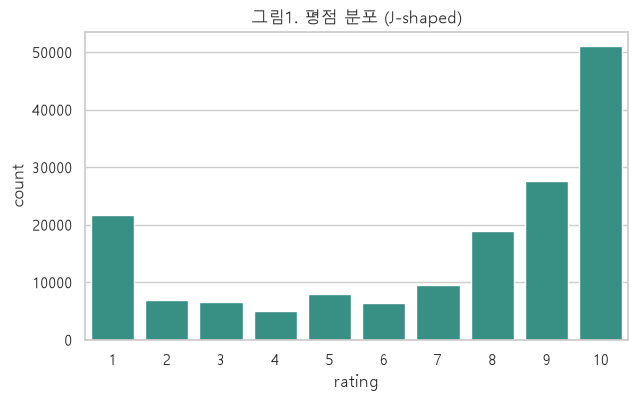

In [9]:
# 그림 1: 평점 분포 (J자형 — 10점/1점 양극단)
fig, ax = plt.subplots()
sns.countplot(x="rating", data=df, color="#2a9d8f", ax=ax)
ax.set_title("그림1. 평점 분포 (J-shaped)")
plt.show()

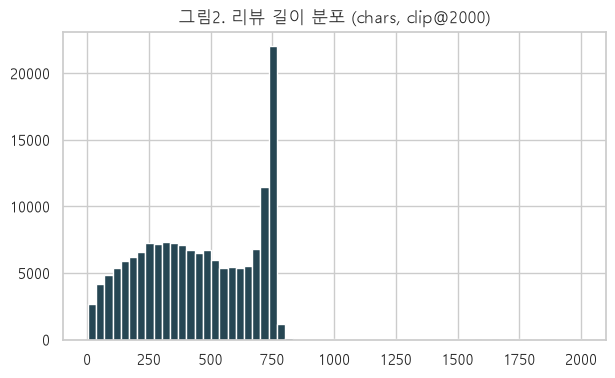

In [10]:
# 그림 2: 리뷰 길이 분포 (문자 수, 2000자에서 clip)
fig, ax = plt.subplots()
feat["review_length"].clip(upper=2000).hist(bins=60, color="#264653", ax=ax)
ax.set_title("그림2. 리뷰 길이 분포 (chars, clip@2000)")
plt.show()

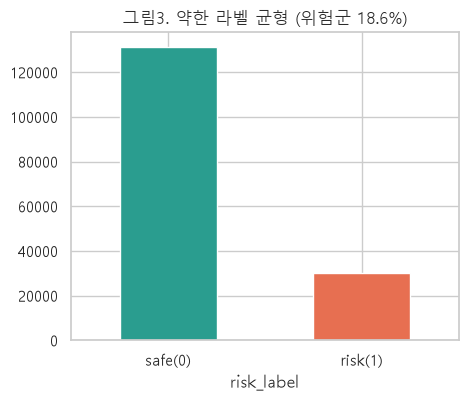

In [11]:
# 그림 3: 위험군/안전군 라벨 균형
fig, ax = plt.subplots(figsize=(5, 4))
feat["risk_label"].map({0: "safe(0)", 1: "risk(1)"}).value_counts().plot.bar(
    color=["#2a9d8f", "#e76f51"], ax=ax)
ax.set_title(f"그림3. 약한 라벨 균형 (위험군 {feat['risk_label'].mean():.1%})")
ax.tick_params(axis="x", rotation=0)
plt.show()

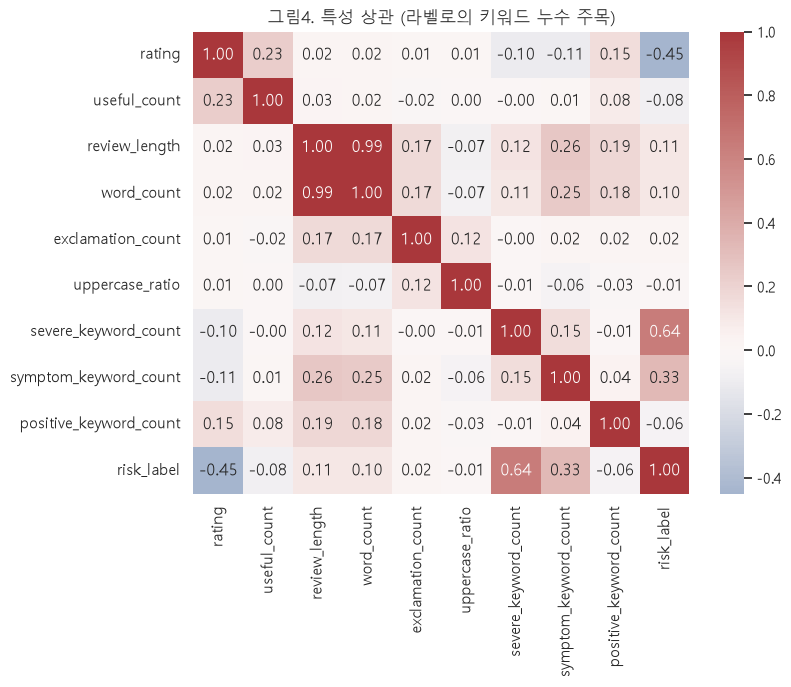

risk_label                1.000
severe_keyword_count      0.642
symptom_keyword_count     0.334
review_length             0.109
word_count                0.100
exclamation_count         0.018
uppercase_ratio          -0.009
positive_keyword_count   -0.059
useful_count             -0.076
rating                   -0.450
Name: risk_label, dtype: float64

In [12]:
# 그림 4: 특성 상관 히트맵 — 누수 단서(severe/symptom 키워드 vs risk_label)
num_cols = ["rating", "useful_count", "review_length", "word_count",
            "exclamation_count", "uppercase_ratio", "severe_keyword_count",
            "symptom_keyword_count", "positive_keyword_count", "risk_label"]
corr = feat[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("그림4. 특성 상관 (라벨로의 키워드 누수 주목)")
plt.show()
corr["risk_label"].sort_values(ascending=False).round(3)

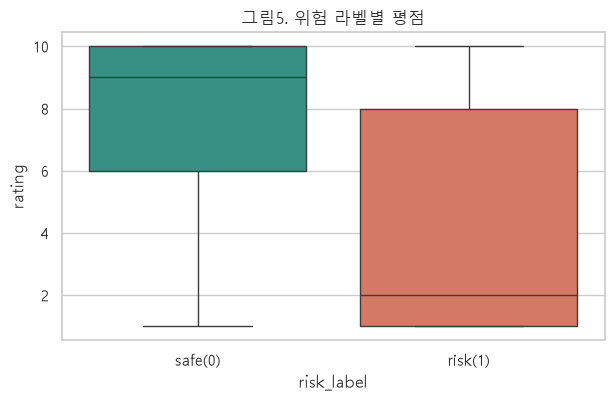

In [13]:
# 그림 5: 위험 라벨별 평점 분포
fig, ax = plt.subplots()
sns.boxplot(x="risk_label", y="rating", hue="risk_label", data=feat,
            palette={0: "#2a9d8f", 1: "#e76f51"}, legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["safe(0)", "risk(1)"])
ax.set_title("그림5. 위험 라벨별 평점")
plt.show()

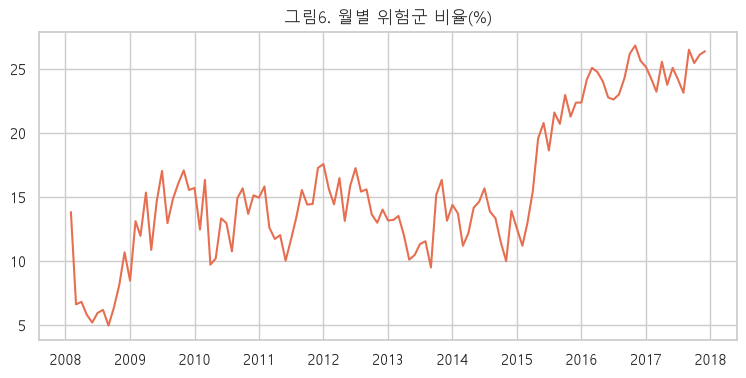

In [14]:
# 그림 6: 월별 위험군 비율 추이
dated = feat.dropna(subset=["date"]).copy()
dated["month"] = dated["date"].dt.to_period("M").dt.to_timestamp()
monthly = dated.groupby("month").agg(risk_ratio=("risk_label", "mean"),
                                      reviews=("review", "count")).reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly["month"], monthly["risk_ratio"] * 100, color="#e76f51")
ax.set_title("그림6. 월별 위험군 비율(%)")
plt.show()

## 4. 특성 엔지니어링 & 타깃 누수(leakage) 스토리

### 4-1. 생성한 특성
원본에는 공식 "심각한 ADE" 라벨이 없어 **약한 라벨(weak label)** 을 투명하게 정의했다.

```
위험군(1) = (심각 키워드 포함)  OR  (평점 ≤ 3  AND  증상 키워드 포함)
```

In [15]:
print("전체 숫자 특성 (NUMERIC_FEATURES):")
print(" ", NUMERIC_FEATURES)
print("\n라벨을 '정의'하는 누수 특성 (모델에서 제외):")
print(" ", LABEL_DEFINING_FEATURES)
print("\n모델에 실제 투입하는 특성 (MODEL_FEATURES):")
print(" ", MODEL_FEATURES)

전체 숫자 특성 (NUMERIC_FEATURES):
  ['rating', 'useful_count', 'review_length', 'word_count', 'exclamation_count', 'uppercase_ratio', 'severe_keyword_count', 'symptom_keyword_count', 'positive_keyword_count', 'low_rating_flag', 'rating_iqr_low_outlier', 'drug_review_count', 'drug_avg_rating']

라벨을 '정의'하는 누수 특성 (모델에서 제외):
  ['severe_keyword_count', 'symptom_keyword_count', 'low_rating_flag']

모델에 실제 투입하는 특성 (MODEL_FEATURES):
  ['rating', 'useful_count', 'review_length', 'word_count', 'exclamation_count', 'uppercase_ratio', 'positive_keyword_count', 'rating_iqr_low_outlier', 'drug_review_count', 'drug_avg_rating']


### 4-2. 누수 before / after

**문제**: 라벨을 정의하는 `severe_keyword_count`, `symptom_keyword_count`, `low_rating_flag`를
그대로 학습에 넣으면 모델은 라벨 생성 '규칙'을 그대로 복원한다 → 비현실적 고성능(규칙 암기).

아래에서 동일한 데이터·모델로 **누수 포함 vs 누수 제거**를 비교한다(속도를 위해 25k 샘플).

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def quick_eval(cols, data):
    y = data["risk_label"].astype(int)
    X = data[["review"] + cols]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    pre = ColumnTransformer([
        ("text", TfidfVectorizer(max_features=800, ngram_range=(1, 2), min_df=2, stop_words="english"), "review"),
        ("num", StandardScaler(), cols),
    ])
    pipe = Pipeline([("pre", pre), ("rf", RandomForestClassifier(
        n_estimators=120, min_samples_leaf=2, class_weight="balanced_subsample",
        random_state=42, n_jobs=-1))])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    return {"accuracy": accuracy_score(yte, pred),
            "f1": f1_score(yte, pred),
            "roc_auc": roc_auc_score(yte, proba)}

sample = feat.sample(min(25_000, len(feat)), random_state=42)
leaky = quick_eval(NUMERIC_FEATURES, sample)    # 누수 포함(라벨 정의 컬럼까지)
honest = quick_eval(MODEL_FEATURES, sample)     # 누수 제거(앱 배포 구성)

compare = pd.DataFrame({"누수 포함 (잘못)": leaky, "누수 제거 (정직)": honest}).T
(compare * 100).round(1)

,accuracy,f1,roc_auc
누수 포함 (잘못),100.0,100.0,100.0
누수 제거 (정직),96.5,89.7,96.6


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_drug_reviews
from src.features import add_features, MODEL_FEATURES, LABEL_DEFINING_FEATURES
import pandas as pd

# 원본 → 특성 엔지니어링 적용
df_raw, _ = load_drug_reviews(max_rows=3000)
df = add_features(df_raw)

original_cols = list(df_raw.columns)
all_cols = list(df.columns)
new_cols = [c for c in all_cols if c not in original_cols]

rows = []
for c in original_cols:
    rows.append({"컬럼": c, "구분": "원본 (raw)", "dtype": str(df[c].dtype)})
for c in new_cols:
    if c in LABEL_DEFINING_FEATURES:
        tag = "⛔ 라벨정의 → 학습 제외"
    elif c in MODEL_FEATURES:
        tag = "✅ 새 특성 (학습)"
    elif c == "risk_label":
        tag = "🎯 target"
    else:
        tag = "파생 (기타)"
    rows.append({"컬럼": c, "구분": tag, "dtype": str(df[c].dtype)})

summary = pd.DataFrame(rows)

def highlight(row):
    color_map = {
        "✅ 새 특성 (학습)":      "background-color:#1a3a1a; color:#deff9a",
        "⛔ 라벨정의 → 학습 제외": "background-color:#3a1a1a; color:#fb7185",
        "🎯 target":              "background-color:#1a1a3a; color:#a855f7",
        "원본 (raw)":             "background-color:#1a1a2a; color:#94a3b8",
    }
    c = color_map.get(row["구분"], "")
    return [c] * len(row)

display(summary.style
    .apply(highlight, axis=1)
    .set_caption("특성 목록 — 원본 7컬럼 + 새로 도출한 특성")
    .set_table_styles([{"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("color","#f8fafc")]}])
    .hide(axis="index")
)

컬럼,구분,dtype
review_id,원본 (raw),int64
drug_name,원본 (raw),object
condition,원본 (raw),object
review,원본 (raw),object
rating,원본 (raw),int64
date,원본 (raw),datetime64[ns]
useful_count,원본 (raw),int64
review_length,✅ 새 특성 (학습),int64
word_count,✅ 새 특성 (학습),int64
exclamation_count,✅ 새 특성 (학습),int64


**해석**: 누수를 포함하면 Accuracy/F1/AUC가 비정상적으로 1.0에 가깝게 나온다(규칙 암기).
누수 컬럼을 제거하면 성능은 내려가지만 **정직한 예측력**을 보고할 수 있고, 상위 특성도
`rating`·`hospital`·`er`·`swelling` 같은 **의미 있는 토큰**으로 바뀐다. 이것이 이 프로젝트의
핵심 분석 교훈이다.

## 5. 결론

- 환자 리뷰 텍스트에는 심각 부작용을 의심할 신호가 담겨 있고, TF-IDF + 평점/행동 특성으로
  단순 규칙을 능가하는 위험군 분류가 가능하다.
- 가장 중요한 점은 **데이터 누수를 발견·제거하여 정직한 성능(F1 ≈ 0.90)** 을 보고한 것이다.
- 한계: 약한 라벨이 텍스트 키워드에서 파생되므로 "키워드의 일반화"이지 미지의 ADE를 새로
  발견하는 것은 아니다. (완곡 표현은 놓칠 수 있음)

> 이 노트북에서 정의·검증한 파이프라인(`src/`)은 Streamlit 앱(`pages/`)이 그대로 재사용하여
> 실시간 서비스로 배포된다 — R&D에서 증명하고 Production이 반영하는 구조.